# **Modeling: Conditional Training với LightGBM**

Notebook này thực hiện conditional training kết hợp LightGBM với các mô hình hồi quy khác:

**Approach:**
- **LightGBM**: Train trên dữ liệu có `quantity_sold < 2` (doanh số thấp)
- **Các model khác**: Train trên dữ liệu có `quantity_sold >= 2` (doanh số cao)
  - ElasticNet (Linear Regression)
  - Random Forest Regressor  
  - XGBoost Regressor

**Output:**
- 3 file prediction kết hợp: `lgbm_enet_predictions.csv`, `lgbm_rf_predictions.csv`, `lgbm_xgb_predictions.csv`
- Mỗi file chứa predictions cho toàn bộ test set (LightGBM cho y<2, model tương ứng cho y>=2)
- So sánh performance của 3 approaches conditional training

## **1. Thiết lập môi trường**

Import hàm conditional training từ file `models.py`

In [1]:
import sys
import os

# thêm thư mục src vào python path
sys.path.append(os.path.abspath("../src"))

from models import (
    train_lgbm_linear_regression_elasticnet,
    train_lgbm_random_forest_regressor,
    train_lgbm_xgboost_regressor,
    run_model_comparison
)

## **2. Kiểm tra dữ liệu**

Kiểm tra vài dòng đầu của dữ liệu.


In [2]:
import pandas as pd

train_df = pd.read_csv("../data/processed/train_data_final.csv")
test_df  = pd.read_csv("../data/processed/test_data_final.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (15848, 67)
Test shape: (3963, 67)


,price,original_price,discount_rate,quantity_sold,rating_average,review_count,is_return_policy,is_freeship_xtra,is_authentic,image_count,...,category_root_name_Điện Thoại - Máy Tính Bảng,category_root_name_Điện Tử - Điện Lạnh,category_root_name_Đồ chơi - Mẹ & Bé,China,Japan,South Korea,Thailand,USA,Vietnam,Others
0,0.445108,0.438575,0.000000,3.828641,0.74,0.331717,1.0,1.0,1.0,0.411765,...,0,0,0,1,1,0,0,0,0,0.00
1,0.313109,0.343930,0.500000,3.828641,1.00,0.367314,1.0,0.0,0.0,0.000000,...,0,0,0,0,0,0,0,0,0,0.25
2,0.156620,0.148556,0.000000,0.000000,0.00,0.000000,0.0,1.0,1.0,0.176471,...,0,0,0,0,0,0,0,0,1,0.00
3,0.263237,0.330742,0.846154,3.218876,0.86,0.310416,1.0,1.0,1.0,0.294118,...,0,0,0,0,0,0,0,0,0,0.25
4,0.396891,0.390102,0.000000,1.945910,0.80,0.175253,1.0,1.0,1.0,0.235294,...,0,0,0,1,0,0,1,0,0,0.00


## **3. LightGBM + Linear Regression**

**Pipeline:**
1. Load train/test
2. Drop leak feature `review_to_sold_ratio`
3. Split train, test theo `quantity_sold < 2` (low) và `quantity_sold >= 2` (high)
4. ElasticNetCV tìm `alpha`, `l1_ratio` cho dữ liệu `quantity_sold >= 2`
5. Train lần 1 -> chọn feature theo `|coef| > threshold`
6. Train final model trên tập feature đã chọn
7. Train tập `quantity_sold <2` với LightGBM
8. Ghép 2 tập high, low thành data full
9. Vẽ Top 10 coef (abs) và lưu ảnh``
10. Predict test và lưu `lgbm_enet_predictions.csv`


Original train size: 15848
Original test size: 3963
Train data with y < 2.0: 8480
Train data with y >= 2.0: 7368
Test data with y < 2.0: 2078
Test data with y >= 2.0: 1885

TRAINING ELASTICNET ON DATA WITH y >= threshold
Best alpha: 0.0001
Best l1_ratio: 0.99
Total selected features: 61
[FINAL MODEL] Number of selected features: 61

TRAINING LIGHTGBM ON DATA WITH y < threshold
LightGBM (y < 2.0) - Best params: {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

COMBINED FEATURE IMPORTANCE (ElasticNet + LightGBM)
ElasticNet weight: 0.465 (n=7368)
LightGBM weight: 0.535 (n=8480)

Top 15 Combined Features:
store_review_count                       110.347054
total_follower                            78.659659
price                                     77.860568
original_price                            77.587077
shop_potential                            70.630994
name_length                               68.534332
price_v

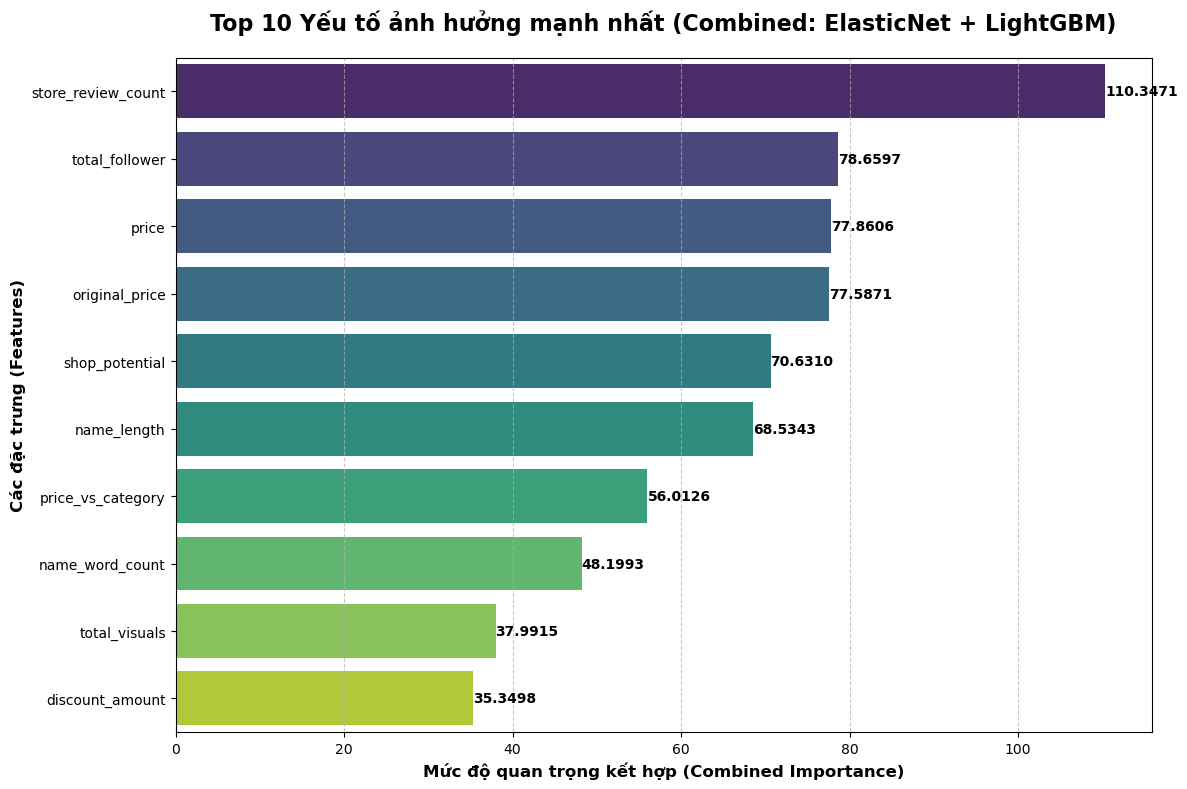

LR metrics: {'MAE': 0.4388806713545489, 'MSE': 0.39346884641601804, 'RMSE': 0.6272709513567626, 'R2': 0.9248009222502451}


,feature,coefficient,abs_coefficient
0,review_count,1.480456,1.480456
1,price_vs_category,-0.782893,0.782893
2,price,0.588258,0.588258
3,store_review_count,0.257887,0.257887
4,category_root_name_Nhà Sách Tiki,0.239370,0.239370
5,category_root_name_Điện Tử - Điện Lạnh,-0.224211,0.224211
6,category_root_name_Làm Đẹp - Sức Khỏe,0.203844,0.203844
7,category_root_name_Chăm sóc nhà cửa,0.193459,0.193459
8,category_root_name_Bách Hóa Online,0.187582,0.187582
9,category_root_name_Ô Tô – Xe Máy – Xe Đạp,-0.182248,0.182248


In [3]:
lr_result = train_lgbm_linear_regression_elasticnet()

print("LR metrics:", lr_result["metrics"])
lr_result["coef_df"].head(10)

## **4. Random Forest Regressor**

**Pipeline:**
1. Load train/test, chia dữ liệu thành high/low theo `quantity_sold`
2. Drop leak feature `review_to_sold_ratio`
2. GridSearchCV tìm best params (scoring = R²), với tập dữ liệu `quantity_sold >= 2`(high)
3. Train tập `quantity_sold <2` với LightGBM
4. Train best estimator → predict test
5. Tính R² và RMSE
6. Vẽ Top 10 feature importance và lưu ảnh
7. Lưu `lgbm_rf_predictions.csv`

Original train size: 15848
Original test size: 3963
Train data with y < 2.0: 8480
Train data with y >= 2.0: 7368
Test data with y < 2.0: 2078
Test data with y >= 2.0: 1885

TRAINING RANDOMFOREST ON DATA WITH y >= threshold
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best RF params:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Random Forest Feature Importances:
review_count                                           0.295419
reputation_score                                       0.259557
total_follower                                         0.055564
store_review_count                                     0.051429
shop_potential                                         0.047891
rating_average                                         0.040281
original_price                                         0.023372
price                                                  0.023129
price_vs_category                       

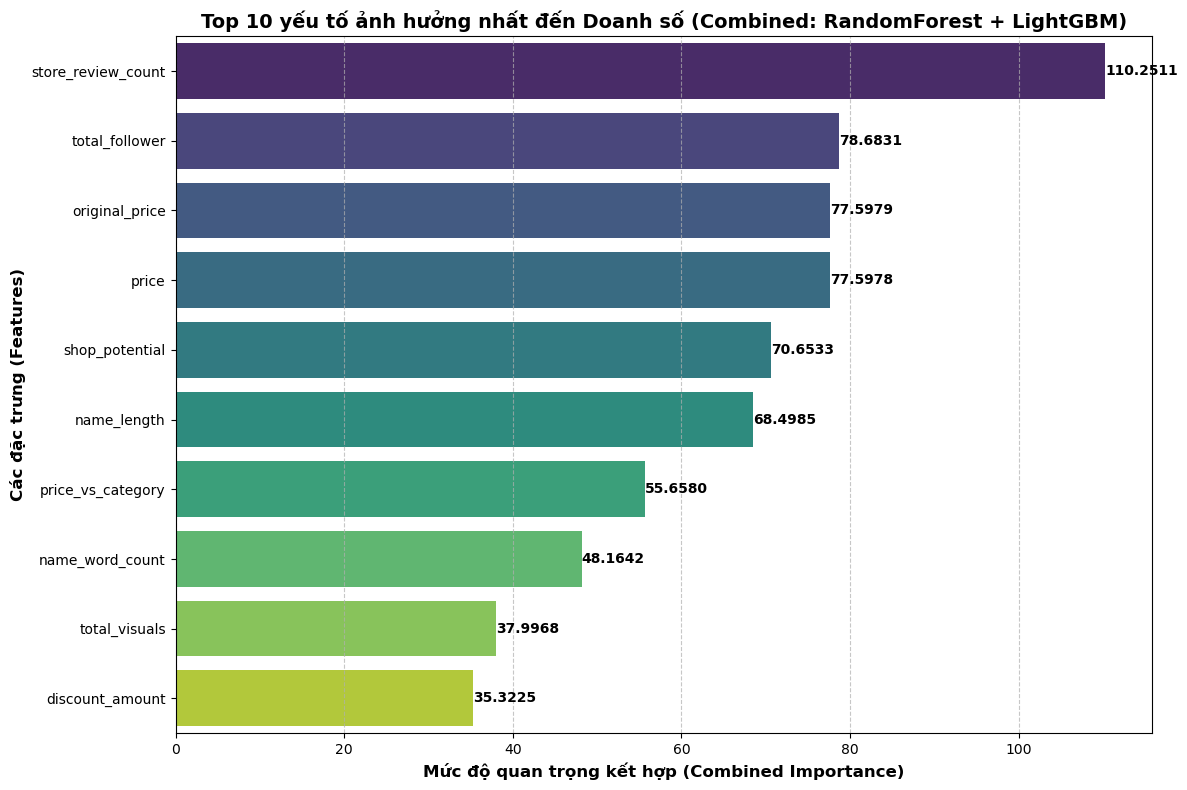

RF metrics: {'R2': 0.9339133335403856, 'RMSE': 0.5880386091467068, 'MAE': 0.4272964328962656}


store_review_count    110.251068
total_follower         78.683076
original_price         77.597943
price                  77.597830
shop_potential         70.653260
name_length            68.498521
price_vs_category      55.658047
name_word_count        48.164159
total_visuals          37.996811
discount_amount        35.322527
dtype: float64

In [4]:
rf_result = train_lgbm_random_forest_regressor()

print("RF metrics:", rf_result["metrics"])
rf_result["combined_feature_importances"].head(10)

## **5. XGBoost Regressor**

**Pipeline:**
1. Load train/test, chia dữ liệu thành high/low theo `quantity_sold`
2. Split train thành train/val = 80/20
3. Train baseline để lấy feature importance ban đầu (early stopping)
4. Loại các cột gây nhiễu trước khi tune/train (`cols_to_drop`)
5. RandomizedSearchCV tìm hyperparameters tốt
6. Train final trên bộ dữ liệu high (train + val)
7. Train tập `quantity_sold <2` với LightGBM
8. Predict test theo 2 tập high, low
8. Đánh giá bằng RMSE/MAE/R²
9. Vẽ Top N feature importance và lưu ảnh
10. Lưu `lgbm_xgb_predictions.csv`

Original train size: 15848
Original test size: 3963
Train data with y < 2.0: 8480
Train data with y >= 2.0: 7368
Test data with y < 2.0: 2078
Test data with y >= 2.0: 1885

TRAINING XGBOOST ON DATA WITH y >= threshold
Feature Importances:
reputation_score                                       0.551626
review_count                                           0.199196
review_to_sold_ratio                                   0.032502
total_follower                                         0.029695
Thailand                                               0.011587
is_brand                                               0.011184
rating_average                                         0.010878
category_root_name_Nhà Sách Tiki                       0.010700
category_root_name_Ô Tô – Xe Máy – Xe Đạp              0.010191
category_root_name_Điện Tử - Điện Lạnh                 0.009127
category_root_name_Làm Đẹp - Sức Khỏe                  0.009034
discount_amount                                        0.

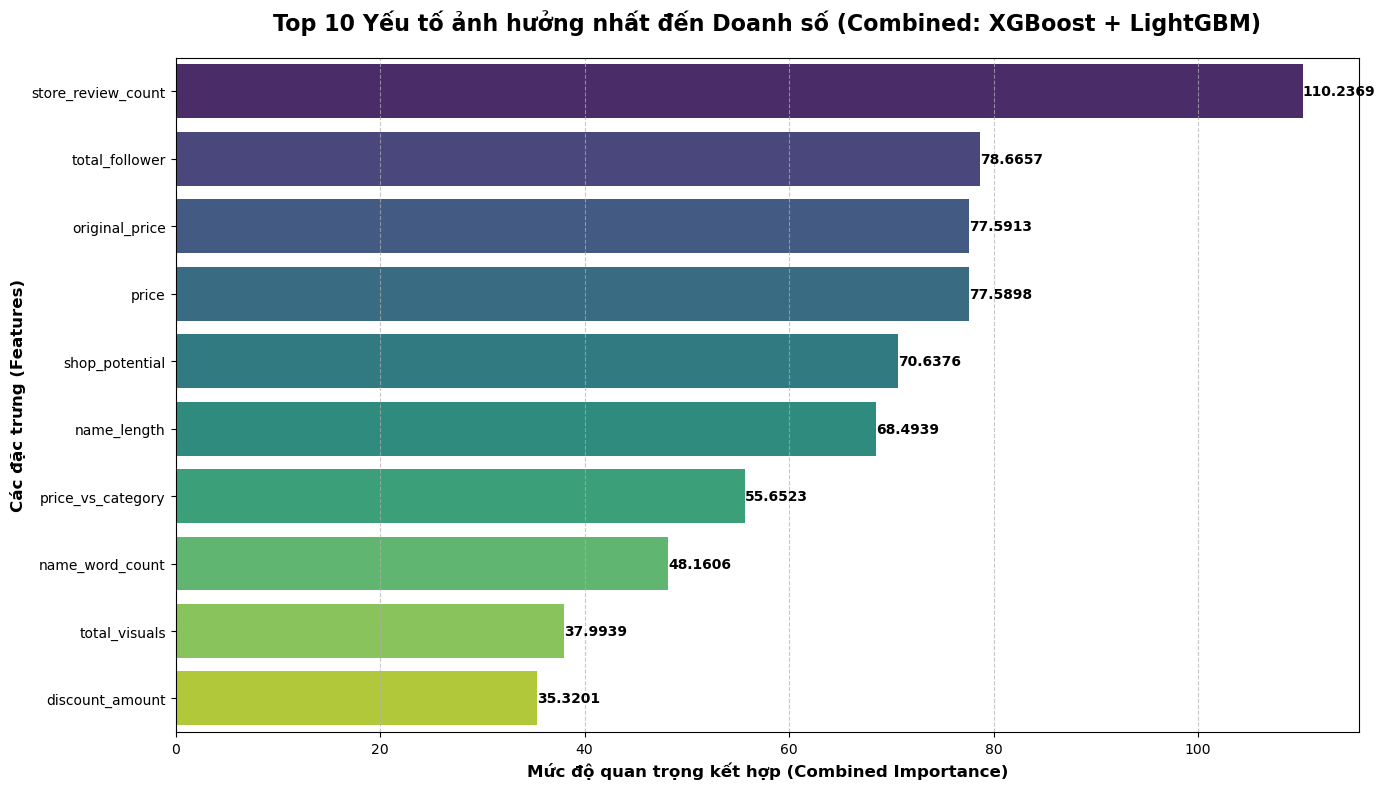

XGB metrics: {'RMSE': 0.5700162316026499, 'MAE': 0.41320086049593985, 'R2': 0.9379021437426828}


In [5]:
xgb_result = train_lgbm_xgboost_regressor()

print("XGB metrics:", xgb_result["metrics"])


In [6]:
xgb_result["combined_feature_importances"].head(10)

store_review_count    110.236922
total_follower         78.665685
original_price         77.591343
price                  77.589762
shop_potential         70.637619
name_length            68.493907
price_vs_category      55.652322
name_word_count        48.160618
total_visuals          37.993938
discount_amount        35.320139
dtype: float64

## **6. So sánh mô hình**

Dùng các file prediction CSV để:
- Tính metric trên log-scale và real-scale
- Vẽ biểu đồ so sánh + scatter predicted vs actual
- Lưu ảnh vào `../data/images/`


                     Model      RMSE       MAE        R²   RMSE Real  \
0    LightGBM + ElasticNet  0.627271  0.438881  0.924801  745.501292   
1  LightGBM + RandomForest  0.588039  0.427296  0.933913  719.582084   
2       LightGBM + XGBoost  0.570016  0.413201  0.937902  644.030733   

     MAE Real   R² Real  
0  133.752135  0.542326  
1  127.179101  0.573597  
2  112.207480  0.658435  
Đã tạo xong file comparison & predicted_vs_actual!


,Model,RMSE,MAE,R²,RMSE Real,MAE Real,R² Real
0,LightGBM + ElasticNet,0.627271,0.438881,0.924801,745.501292,133.752135,0.542326
1,LightGBM + RandomForest,0.588039,0.427296,0.933913,719.582084,127.179101,0.573597
2,LightGBM + XGBoost,0.570016,0.413201,0.937902,644.030733,112.207480,0.658435


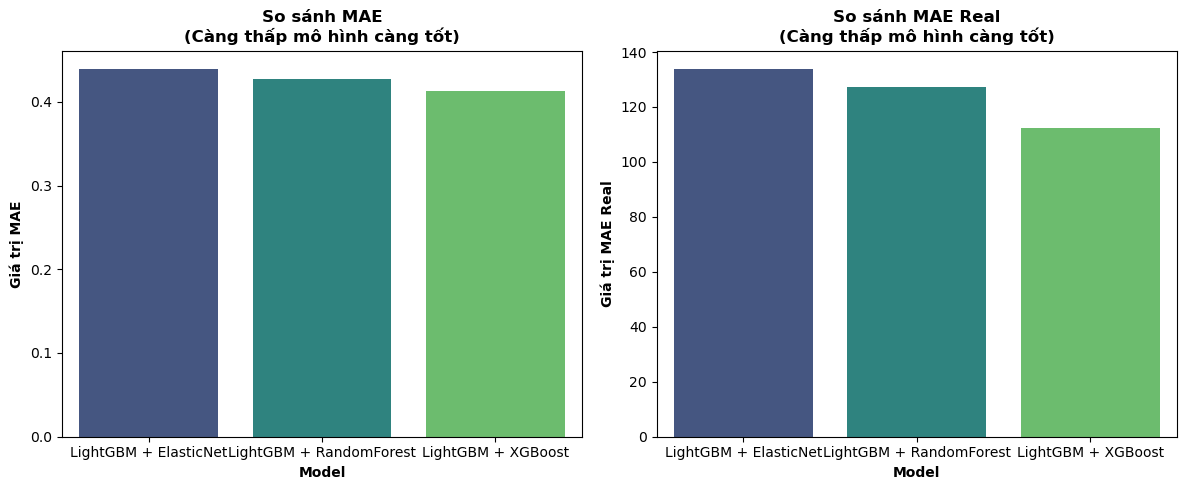

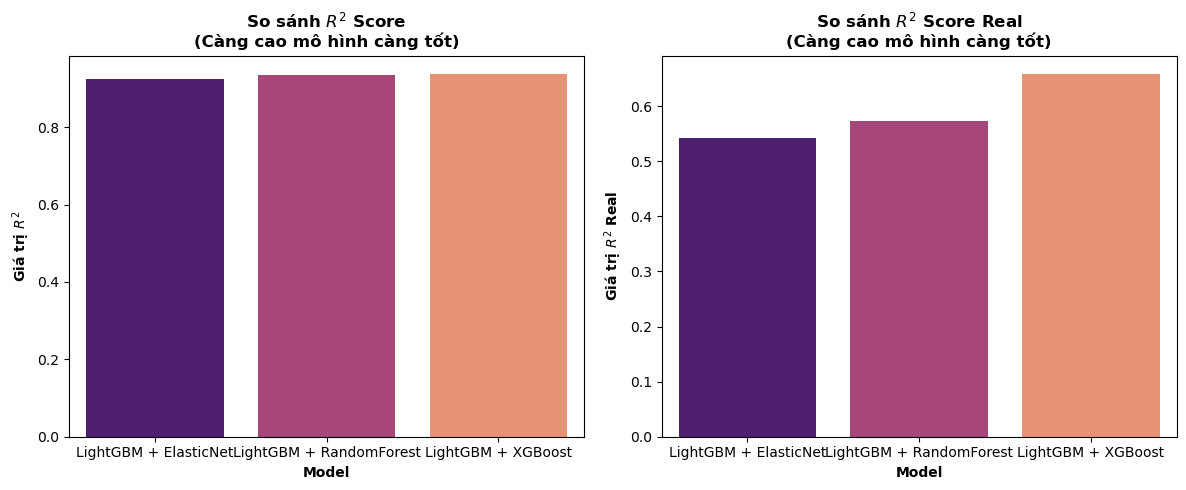

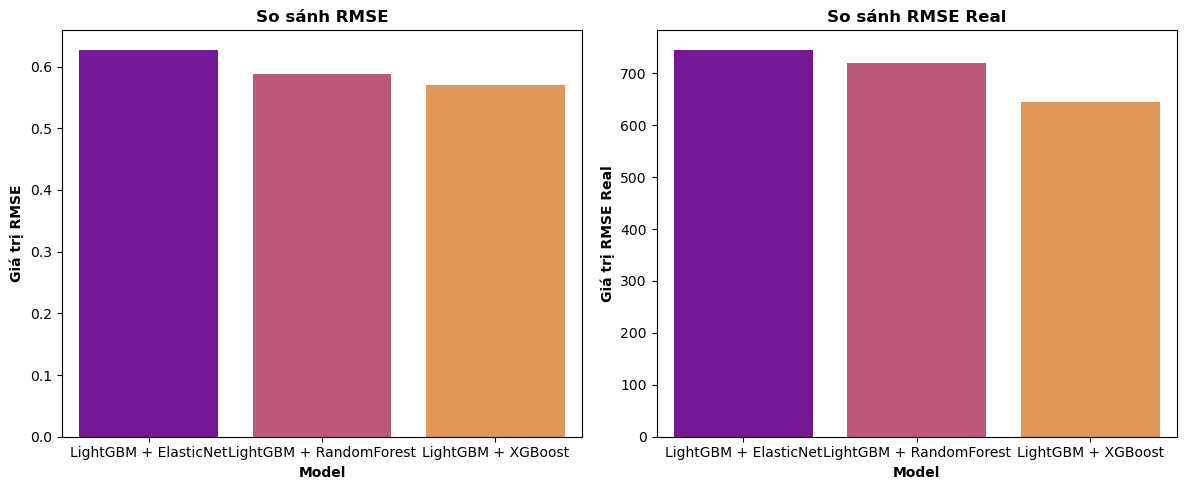

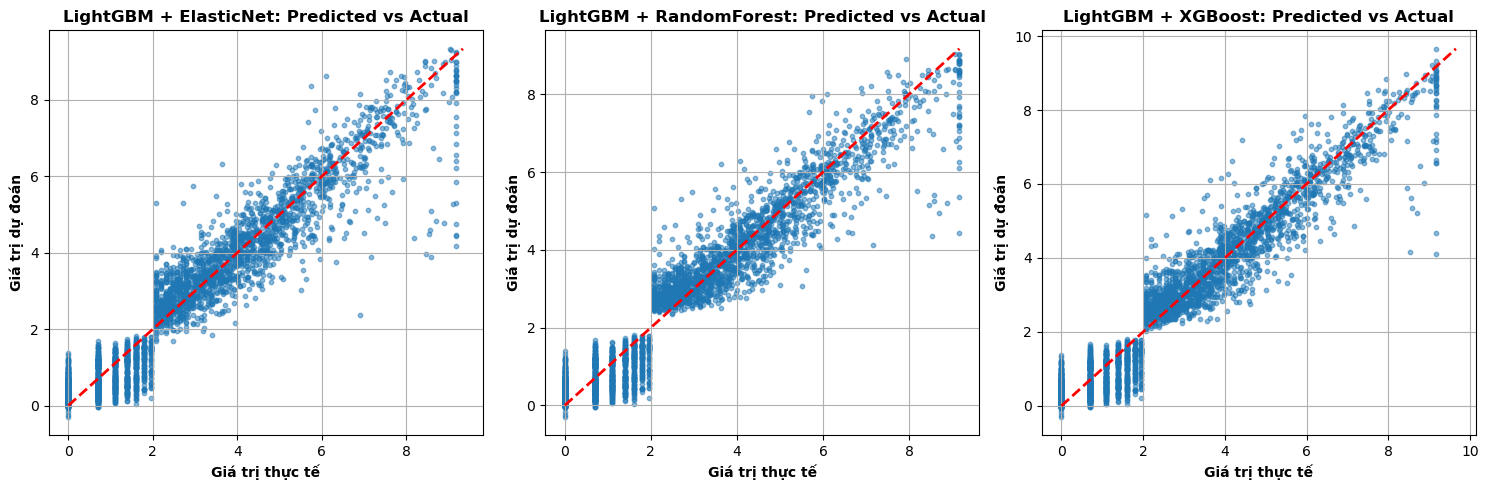

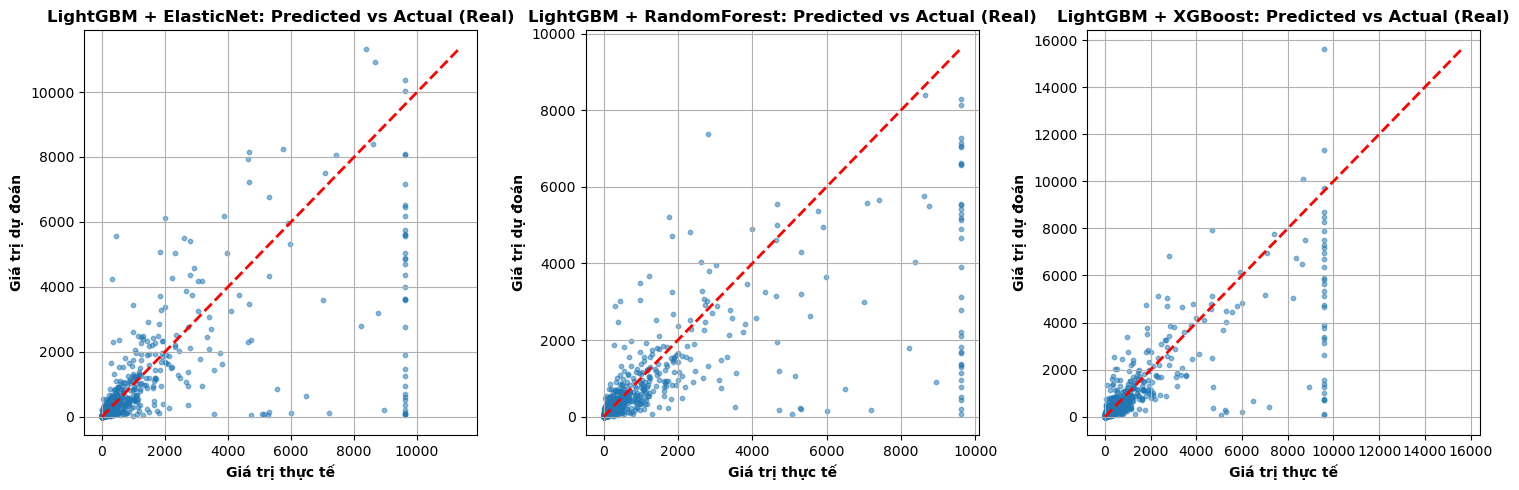

In [7]:
comparison_df = run_model_comparison()
comparison_df